In [ ]:
import os
import torch
from diffusers import StableDiffusionPipeline
from datasets import load_dataset
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display
from google.colab import drive

In [ ]:
# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to your dataset folder in Drive
dataset_path = "/content/drive/MyDrive/Web-Harvested"

In [ ]:
data_csv = os.path.join(dataset_path, "data.csv")
data_img_dir = os.path.join(dataset_path, "data_images")

In [ ]:
import pandas as pd
# 2️⃣ Load datasets
dataset = load_dataset("csv", data_files=data_csv)['train']

print(f"Number of data examples: {len(dataset)}")
print("Sample entry:", dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Number of data examples: 3318333
Sample entry: {'image_url': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800', 'caption': 'a very typical bus station'}


In [ ]:
# Downsample dataset to 7000 entries
dataset = dataset.shuffle(seed=42).select(range(7000))

print(f"Downsampled number of examples: {len(dataset)}")
print("Sample entry after downsampling:", dataset[0])

Downsampled number of examples: 7000
Sample entry after downsampling: {'image_url': 'http://cdn.cnn.com/cnnnext/dam/assets/141216085641-19-peshawar-1216-horizontal-large-gallery.jpg', 'caption': 'a soldier clears the area outside the school .'}


In [ ]:
import random
import requests
from datasets import load_dataset

# 1️⃣ Load the full dataset
dataset = load_dataset("csv", data_files=data_csv)['train']
print(f"Original number of examples: {len(dataset)}")

# 2️⃣ Randomly select 7000 entries first
random.seed(42)
if len(dataset) > 7000:
    subset_indices = random.sample(range(len(dataset)), 7000)
else:
    subset_indices = list(range(len(dataset)))

subset_dataset = dataset.select(subset_indices)
print(f"Number of entries selected for URL validation: {len(subset_dataset)}")

# 3️⃣ Function to test if a URL is valid
def is_url_valid(url, timeout=5):
    try:
        response = requests.head(url, timeout=timeout)
        return response.status_code == 200
    except:
        return False

# 4️⃣ Keep only entries with valid URLs
valid_entries = [entry for entry in subset_dataset if is_url_valid(entry['image_url'])]
print(f"Number of valid URLs after checking: {len(valid_entries)}")

# 5️⃣ Extract valid URLs (optional)
valid_image_urls = [entry['image_url'] for entry in valid_entries]
print(f"First 5 valid image URLs: {valid_image_urls[:5]}")

Original number of examples: 3318333
Number of entries selected for URL validation: 7000
Number of valid URLs after checking: 2244
First 5 valid image URLs: ['https://previews.123rf.com/images/piksel/piksel1506/piksel150600070/41255790-family-of-four-hugging-each-other-Stock-Photo.jpg', 'https://i.pinimg.com/736x/f4/4d/6c/f44d6cfe185c9eff57553e4690219b1f--outfits-for-women-vintage-outfits.jpg', 'https://us.123rf.com/450wm/foteeva/foteeva1710/foteeva171000037/88303412-representing-the-seasons-of-the-year-through-the-alarm-clock-and-natural-material-on-a-white-backgro.jpg?ver=6', 'https://media.istockphoto.com/photos/grass-together-in-a-group-picture-id500725159?k=6&m=500725159&s=612x612&w=0&h=hB0H4f4GYAJMgL8xMmL9L9VuU2I8RZDU2vQptLmjeA4=', 'https://i.pinimg.com/736x/f7/8f/50/f78f504274c4efcab62a575e6c07e307--wooden-kitchen-cabinets-kitchen-cabinet-design.jpg']


In [ ]:
# Paths in Drive
save_dir = "/content/drive/MyDrive/Web-Harvested/valid_images"
os.makedirs(save_dir, exist_ok=True)

# Save captions in a new CSV
captions = []

def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=10)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        image.save(save_path)
        return True
    except Exception as e:
        print(f"❌ Failed to download {url} → {e}")
        return False

print("\n📥 Starting image download...\n")

for i, entry in enumerate(valid_entries):
    url = entry["image_url"]
    caption = entry["caption"]

    img_path = os.path.join(save_dir, f"img_{i}.jpg")

    if download_image(url, img_path):
        captions.append({"image_path": img_path, "caption": caption})
        print(f"✔ Downloaded {i+1}/{len(valid_entries)}")
    else:
        print(f"⏭ Skipped {url}")

# Save the captions to Drive
captions_df = pd.DataFrame(captions)
captions_csv = "/content/drive/MyDrive/Web-Harvested/valid_captions.csv"
captions_df.to_csv(captions_csv, index=False)

print("\n🎉 DONE!")
print(f"Downloaded images saved to: {save_dir}")
print(f"Captions CSV saved to: {captions_csv}")


📥 Starting image download...

✔ Downloaded 1/2244
✔ Downloaded 2/2244
✔ Downloaded 3/2244
✔ Downloaded 4/2244
✔ Downloaded 5/2244
✔ Downloaded 6/2244
✔ Downloaded 7/2244
✔ Downloaded 8/2244
✔ Downloaded 9/2244
✔ Downloaded 10/2244
✔ Downloaded 11/2244
✔ Downloaded 12/2244
✔ Downloaded 13/2244
✔ Downloaded 14/2244
✔ Downloaded 15/2244
✔ Downloaded 16/2244
✔ Downloaded 17/2244
❌ Failed to download https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=1909413415984505 → cannot identify image file <_io.BytesIO object at 0x7c19f5d150d0>
⏭ Skipped https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=1909413415984505
✔ Downloaded 19/2244
✔ Downloaded 20/2244
✔ Downloaded 21/2244
✔ Downloaded 22/2244
✔ Downloaded 23/2244
✔ Downloaded 24/2244
✔ Downloaded 25/2244
✔ Downloaded 26/2244
✔ Downloaded 27/2244
✔ Downloaded 28/2244
✔ Downloaded 29/2244
✔ Downloaded 30/2244
✔ Downloaded 31/2244
✔ Downloaded 32/2244
✔ Downloaded 33/2244
✔ Downloaded 34/2244
✔ Downloaded 35/2244
✔ Downl

In [ ]:
# Install required packages
# Run in a Colab cell (prefix with `!`)
!pip install -q git+https://github.com/huggingface/diffusers.git transformers accelerate safetensors ftfy regex einops datasets
# optional but recommended for speed and memory (install if supported in your runtime):
!pip install -q xformers || true

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 8.2 MB/s eta 0:00:00


In [ ]:
# Clone the Hugging Face diffusers examples (has LoRA/text-to-image training examples)
!git clone https://github.com/huggingface/diffusers.git

Cloning into 'diffusers'...
remote: Enumerating objects: 113175, done.
remote: Counting objects: 100% (634/634), done.
remote: Compressing objects: 100% (384/384), done.
remote: Total 113175 (delta 486), reused 249 (delta 249), pack-reused 112541 (from 3)
Receiving objects: 100% (113175/113175), 87.36 MiB | 17.06 MiB/s, done.
Resolving deltas: 100% (84402/84402), done.


In [ ]:
! /content/drive/MyDrive/Web-Harvested/valid_images/   # contains img_0.jpg, img_1.jpg, ...
! /content/drive/MyDrive/Web-Harvested/valid_captions.csv  # contains (image_path, caption) pairs

/bin/bash: line 1: /content/drive/MyDrive/Web-Harvested/valid_images/: Is a directory
/bin/bash: line 1: /content/drive/MyDrive/Web-Harvested/valid_captions.csv: Permission denied


In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import notebook_login
notebook_login()   # this will prompt you to paste your token

In [ ]:
# Change these paths and hyperparams as needed
TRAIN_DIR="/content/drive/MyDrive/Web-Harvested/valid_images"
ANNOTATIONS="/content/drive/MyDrive/Web-Harvested/valid_captions.csv"
OUTPUT_DIR="/content/drive/MyDrive/Web-Harvested/lora_sd_v1_5"
MODEL_ID="runwayml/stable-diffusion-v1-5"

# Create output dir
! mkdir -p $OUTPUT_DIR

# Launch training (example). This uses a community script name; adjust script path if needed.
# Note: You might find train_text_to_image_lora.py at diffusers/examples/community/train_text_to_image_lora.py
# Use accelerate launch to get correct device handling
!accelerate launch \
  diffusers/examples/community/train_text_to_image_lora.py \
  --pretrained_model_name_or_path $MODEL_ID \
  --output_dir $OUTPUT_DIR \
  --train_data_dir $TRAIN_DIR \
  --train_annotation_file $ANNOTATIONS \
  --resolution 512 \
  --random_flip \
  --max_train_steps 2000 \
  --learning_rate 1e-4 \
  --train_batch_size 1 \
  --gradient_accumulation_steps 2 \
  --mixed_precision fp16 \
  --save_every_n_steps 500 \
  --checkpointing_steps 500 \
  --seed 42

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/bin/python3: can't open file '/content/diffusers/examples/community/train_text_to_image_lora.py': [Errno 2] No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/accelerate", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/accelerate/commands/accelerate_cli.py", line 50, in main
    args.func(args)
  File "/usr/local/lib/python3.12/dist-packages/accelerate/commands/launch.py", line 1281, in launch_command
    simple_launcher(args)
  File "/usr/local/lib/python3.12/dist-packages/accelerate/commands/launch.py", line 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Please inspect the OUTPUT_DIR to find saved LoRA files. Adjust loading method according to saved format.


  0%|          | 0/25 [00:00<?, ?it/s]

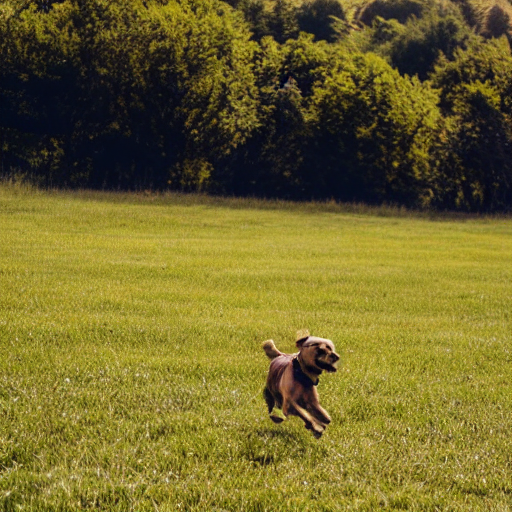

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from pathlib import Path

model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load base pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16 if device=="cuda" else torch.float32)
pipe = pipe.to(device)
if device == "cuda":
    pipe.enable_attention_slicing()

# Load LoRA / attention processors
lora_dir = "/content/drive/MyDrive/Web-Harvested/lora_sd_v1_5"
# many community scripts save LoRA as "unet_lora.safetensors" or as attn_procs folder
# If script saved "attn_procs" folder, you can load them with:
if (Path(lora_dir) / "attn_procs").exists():
    pipe.unet.load_attn_procs(str(Path(lora_dir) / "attn_procs"))
else:
    # if the script saved a single file (e.g. unet_lora.safetensors), some loading utilities or the script provide a loader
    # otherwise you might need to call a small helper to load LoRA weights into pipe.unet
    print("Please inspect the OUTPUT_DIR to find saved LoRA files. Adjust loading method according to saved format.")

# Now generate
prompt = "a dog running on a green field with a blue sky"
image = pipe(prompt, num_inference_steps=25).images[0]
from IPython.display import display
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

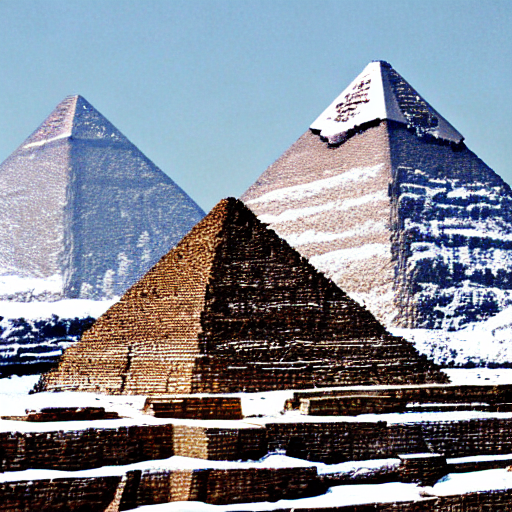

In [ ]:
# Now generate
prompt = "Pyramids with snow"
image = pipe(prompt, num_inference_steps=50).images[0]
from IPython.display import display
display(image)